<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/cat_v_dogs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:07<00:00, 146MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
# !pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras import regularizers


In [5]:
# generators : divides data into batches and RAM works with batches

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256),

)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [6]:
# Normalize :

def process(image,label):
   image = tf.cast(image/255. , tf.float32)
   return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [7]:
# create CNN model :

model = Sequential()

# convolution and pooling layers :

model.add(Conv2D(32,kernel_size = (3,3), padding='same' , activation = 'relu' , input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = 2 , padding = 'valid'))

model.add(Conv2D(64,kernel_size = (3,3), padding='same' , activation = 'relu' ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = 2 , padding = 'valid'))

model.add(Conv2D(128,kernel_size = (3,3), padding='same' , activation = 'relu' ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = 2 , padding = 'valid'))


model.add(Conv2D(128,kernel_size = (3,3), padding='same' , activation = 'relu' ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = 2 , padding = 'valid'))

# Flatten
model.add(Flatten())

# fully connected layers :

model.add(Dense(128,activation = 'relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(64,activation = 'relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,444,993 (16.96 MB)

 Trainable params: 4,444,289 (16.95 MB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
# compile

model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [10]:
history = model.fit(train_ds , epochs = 10 , validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/step - accuracy: 0.5549 - loss: 1.3265 - val_accuracy: 0.5588 - val_loss: 0.9900
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.6341 - loss: 0.8608 - val_accuracy: 0.6944 - val_loss: 0.7237
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7284 - loss: 0.6346 - val_accuracy: 0.6974 - val_loss: 0.6637
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7800 - loss: 0.5623 - val_accuracy: 0.8148 - val_loss: 0.5592
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.8338 - loss: 0.5205 - val_accuracy: 0.8512 - val_loss: 0.5093
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8809 - loss: 0.4671 - val_accuracy: 0.8886 - val_loss: 0.4962
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9079 - loss: 0.4401 - val_accuracy: 0.8762 - val_loss: 0.5127
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9271 - loss: 0.4040 - 

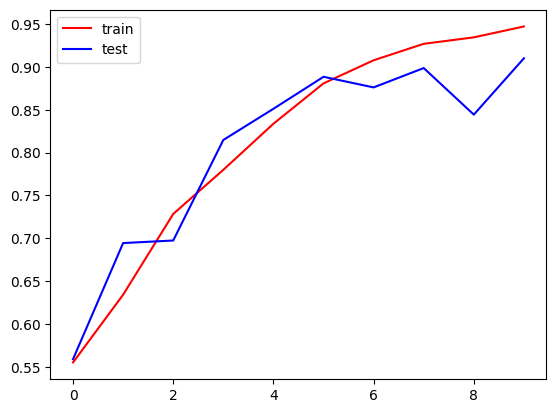

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color = 'red' , label = 'train')
plt.plot(history.history['val_accuracy'],color = 'blue' , label = 'test')
plt.legend()
plt.show()


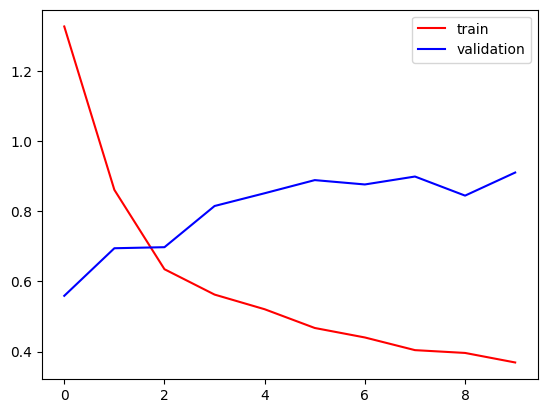

In [12]:
plt.plot(history.history['loss'],color='red',label = 'train')
plt.plot(history.history['val_accuracy'],color='blue',label = 'validation')
plt.legend()
plt.show()

In [16]:
# prediction :

import cv2

In [20]:
test_img = cv2.imread('/content/dog.jpg')

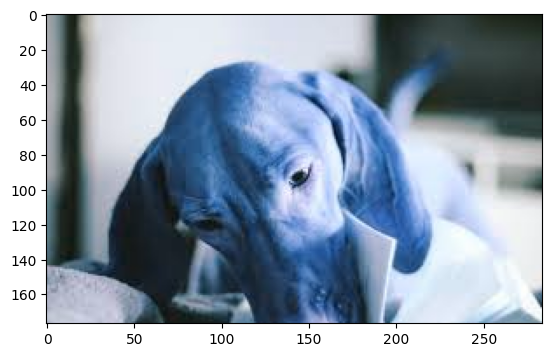

In [21]:
plt.imshow(test_img)

In [22]:
test_img.shape

(177, 284, 3)

In [23]:
test_img = cv2.resize(test_img,(256,256))


In [24]:
test_input = test_img.reshape(1,256,256,3)

In [25]:
model.predict(test_input) # 1 dog . 0 dog

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)